In [ ]:
# Module1_DemoLab_LinearRegression.ipynb

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, PolynomialFeatures)
from scipy.stats import boxcox
from scipy.special import boxcox as bc_fixed
from scipy.special import inv_boxcox
import pandas as pd

# read dataset
boston = pd.read_pickle("data/boston_housing_clean.pickle")
boston_data = boston['dataframe']

lr = LinearRegression()
# segregate x and y data
X = boston_data.drop('MEDV', axis=1) # drop the target column
y = boston_data['MEDV']

# create PolynomialFeatures
pf = PolynomialFeatures(degree=2, include_bias=False)
X_pf = pf.fit_transform(X)  # transform the features data for polynomial features on the X dataset

# extract training and test datasets
X_train, X_test, y_train, y_test = train_test_split(X_pf, y, test_size=0.3, random_state=72018)

# scale the training features data
s = StandardScaler()
X_train_s = s.fit_transform(X_train)

bc_result2 = boxcox(y_train) # transform the training target data using boxcox()
y_train_bc = bc_result2[0]  # the transformed target variable
lam2 = bc_result2[1]        # the lambda: power used for the transformation.

lr.fit(X_train_s, y_train_bc) # train model with the training dataset

X_test_s = s.transform(X_test)    # why do we use transform() instead of fit_transform() ?
y_pred_bc = lr.predict(X_test_s)  # generate the predicted result with the above transformed testing data

# Use the transformed test target and the predictions (which are also on the transformed scale)
y_test_bc = bc_fixed(y_test, lam2)
r2_transformed = r2_score(y_test_bc, y_pred_bc)
print(f"R2 in Transformed Space: {r2_transformed:.4f}")

y_pred_original = inv_boxcox(y_pred_bc, lam2)
display(y_pred_original[:10])
display(y_test.values[:10])

# R-square: compare to the original, untransformed y_test
r2_original = r2_score(y_test, y_pred_original)
print(f"R2 in Original Space: {r2_original:.4f}")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline


df = pd.read_csv("data/cleaned_hotEncoded_car_data.csv")

# allocate training and testing data
X_train, X_test, y_train, y_test = train_test_split( df, y, test_size=0.30, random_state=42)

# scale the training features
ss = StandardScaler()
X_train_s = ss.fit_transform(X_train)



# train the model
lm = LinearRegression()
lm.fit(X_train_s,y_train)

# scale the testing features
X_test_s = ss.transform(X_test)

# predict with test data
car_price_predictions = lm.predict(X_test_s)

# verify predictions
print("Verify predictions...")
display(f"mean squared error: {mean_squared_error(y_test, car_price_predictions)}")
display(f"lm score: {lm.score(X_test_s,y_test)}")
display(f"r2 score: {r2_score(y_test,car_price_predictions)}")


# using pipeline
steps=[('scaler', StandardScaler()), ('lm',  LinearRegression())]
pipe = Pipeline(steps=steps)
pipe.fit(X_train,y_train)
car_price_predictions = pipe.predict(X_test)

# verify predictions from pipeline
print("\n\nVerify Pipeline predictions...")
mse = mean_squared_error(y_test, car_price_predictions)
display(f"mean squared error: {mse}")
display(f"rmse: {np.sqrt(mse)}")
display(f"r2 score: {r2_score(y_test, car_price_predictions)}")





In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

 
data = pd.read_csv("data/Ames_Housing_Sales.csv")

## Determine potential number of additional columns when performing One-Hot-Encoding

numeric_cols     = data.select_dtypes(include=['number']).columns
categorical_cols = data.select_dtypes(exclude=['number']).columns
# Determine how many extra columns would be created when performing one-hot-encoding
num_ohc_cols = data[categorical_cols].apply(lambda x: x.nunique(dropna = False)).sort_values(ascending=False)

# No need to encode if there is only one value
small_num_ohc_cols = num_ohc_cols.loc[num_ohc_cols>1]

# Number of one-hot columns is one less than the number of categories
small_num_ohc_cols -= 1


## One Hot Encoding

# Copy of the data
# data_ohc = data.copy()
data_ohc = data.drop(numeric_cols, axis=1)

# The encoders
le = LabelEncoder()
ohc = OneHotEncoder()

for col in small_num_ohc_cols.index:
    # Integer encode the string categories
    dat = le.fit_transform(data_ohc[col]).astype(int)
    
    # Remove the original column from the dataframe
    data_ohc = data_ohc.drop(col, axis=1)

    # One hot encode the data--this returns a sparse array
    new_dat = ohc.fit_transform(dat.reshape(-1,1))

    # Create unique column names
    n_cols = new_dat.shape[1]
    col_names = ['_'.join([col, str(x)]) for x in range(n_cols)]

    # Create the new dataframe
    new_df = pd.DataFrame(new_dat.toarray(), index=data_ohc.index, columns=col_names)

    # Accumulate the new data to the dataframe
    data_ohc = pd.concat([data_ohc, new_df], axis=1)

# Remove the original string columns from the dataframe
data = data.drop(num_ohc_cols.index, axis=1)

print(f"data.shape: {data.shape}")
print(f"data_ohc.shape: {data_ohc.shape}")


In [7]:
## A better way to do the same for the above.

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

data = pd.read_csv("data/Ames_Housing_Sales.csv")
categorical_cols = data.select_dtypes(exclude=['number']).columns

# Determine how many extra columns would be created when performing one-hot-encoding
num_ohc_cols = data[categorical_cols].apply(lambda x: x.nunique(dropna = False)).sort_values(ascending=False)

data_ohc = data.copy()

# 1. Initialize the encoder
# sparse_output=False makes it return a normal array instead of a "sparse" one
# handle_unknown='ignore' prevents crashes if new data has a weird category
ohc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 2. Apply it directly to your string columns
# OneHotEncoder will "learn" the strings and "transform" them into 1s and 0s in one shot
ohc_data = ohc.fit_transform(data[categorical_cols])

# 3. Get the column names automatically!
# This replaces that manual '_'.join() list comprehension
new_col_names = ohc.get_feature_names_out(categorical_cols)

# 4. Create the final DataFrame
ohe_df = pd.DataFrame(ohc_data, columns=new_col_names, index=data.index)

# 5. COMBINE the numerical columns (from 'data') with the new OHE columns
# We use pd.concat to glue the numerical features and the categorical features together
numerical_data = data.select_dtypes(include=['number'])
data_ohc = pd.concat([numerical_data, ohe_df], axis=1)

# Remove the original string columns from the dataframe
data = data.drop(num_ohc_cols.index, axis=1)




from sklearn.model_selection import train_test_split

y_col = 'SalePrice'

# Split the data that is not one-hot encoded
feature_cols = [x for x in data.columns if x != y_col]
X_data = data[feature_cols]
y_data = data[y_col]
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# Split the data that is one-hot encoded
feature_cols = [x for x in data_ohc.columns if x != y_col]
X_data_ohc = data_ohc[feature_cols]
y_data_ohc = data_ohc[y_col]
X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc = train_test_split(X_data_ohc, y_data_ohc, test_size=0.3, random_state=42)

# Compare the indices to ensure they are identical
# (X_train_ohc.index == X_train.index).all()
print(f"X_train_ohc shape: {X_train_ohc.shape}")
print(f"X_train shape: {X_train.shape}")


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

LR_no_enc = LinearRegression()
LR_ohc = LinearRegression()

# Storage for error values
error_df = list()

# Data that have not been one-hot encoded
LR_no_enc = LR_no_enc.fit(X_train, y_train)
y_train_pred = LR_no_enc.predict(X_train)
y_test_pred = LR_no_enc.predict(X_test)

error_df.append(pd.Series({'train': mean_squared_error(y_train, y_train_pred),
                           'test' : mean_squared_error(y_test,  y_test_pred)},
                           name='no enc'))


# Data that have been one-hot encoded
LR_ohc = LR_ohc.fit(X_train_ohc, y_train_ohc)
y_train_ohc_pred = LR_ohc.predict(X_train_ohc)
y_test_ohc_pred = LR_ohc.predict(X_test_ohc)

error_df.append(pd.Series({'train': mean_squared_error(y_train_ohc, y_train_ohc_pred),
                           'test' : mean_squared_error(y_test_ohc,  y_test_ohc_pred)},
                          name='one-hot enc'))

# Assemble the results
error_df = pd.concat(error_df, axis=1)
error_df

X_train_ohc shape: (965, 294)
X_train shape: (965, 36)


,no enc,one-hot enc
train,1.131507e+09,3.177267e+08
test,1.372182e+09,8.065328e+09


In [8]:
print(f"No Enc R2: {LR_no_enc.score(X_test, y_test)}")
print(f"OHC R2: {LR_ohc.score(X_test_ohc, y_test_ohc)}")

No Enc R2: 0.7727012498678184
OHC R2: -0.33600237067288163


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso

# Mute the sklearn warning about regularization
import warnings
warnings.filterwarnings('ignore', module='sklearn')

# import data
data = pd.read_csv("data/X_Y_Sinusoid_Data.csv")
print("data.head():")
display(data.head())

# generate theoretical Sine Wave data
X_real = np.linspace(0, 1.0, 100)
Y_real = np.sin(2 * np.pi * X_real)
print("\nY_real:")
display(Y_real)

# Setup the polynomial features
degree = 20
pf = PolynomialFeatures(degree)
lr = LinearRegression()

# Extract the X- and Y- data from the dataframe 
X_data = data[['x']]  # double-bracket is needed to return a dataframe since pf.fit_transform() expects a dataframe or 2D array
Y_data = data['y']    # does not need double-bracket since lr.fit() can accept a Series or 1D array

# Create the features and fit the model
X_poly = pf.fit_transform(X_data) # create polynomial-features
lr = lr.fit(X_poly, Y_data)
Y_pred = lr.predict(X_poly)

# The ridge regression model
rr = Ridge(alpha=0.001)
rr = rr.fit(X_poly, Y_data)
Y_pred_rr = rr.predict(X_poly)

# The lasso regression model
lassor = Lasso(alpha=0.0001)
lassor = lassor.fit(X_poly, Y_data)
Y_pred_lr = lassor.predict(X_poly)



data.head():


,x,y
0,0.038571,0.066391
1,0.166776,1.027483
2,0.183153,1.245302
3,0.187359,1.004781
4,0.243116,1.264121



Y_real:


array([ 0.00000000e+00,  6.34239197e-02,  1.26592454e-01,  1.89251244e-01,
        2.51147987e-01,  3.12033446e-01,  3.71662456e-01,  4.29794912e-01,
        4.86196736e-01,  5.40640817e-01,  5.92907929e-01,  6.42787610e-01,
        6.90079011e-01,  7.34591709e-01,  7.76146464e-01,  8.14575952e-01,
        8.49725430e-01,  8.81453363e-01,  9.09631995e-01,  9.34147860e-01,
        9.54902241e-01,  9.71811568e-01,  9.84807753e-01,  9.93838464e-01,
        9.98867339e-01,  9.99874128e-01,  9.96854776e-01,  9.89821442e-01,
        9.78802446e-01,  9.63842159e-01,  9.45000819e-01,  9.22354294e-01,
        8.95993774e-01,  8.66025404e-01,  8.32569855e-01,  7.95761841e-01,
        7.55749574e-01,  7.12694171e-01,  6.66769001e-01,  6.18158986e-01,
        5.67059864e-01,  5.13677392e-01,  4.58226522e-01,  4.00930535e-01,
        3.42020143e-01,  2.81732557e-01,  2.20310533e-01,  1.58001396e-01,
        9.50560433e-02,  3.17279335e-02, -3.17279335e-02, -9.50560433e-02,
       -1.58001396e-01, -

coefficients:


,linear regression,ridge regression,lasso regression
0,2.008356e+08,0.000000,0.000000
1,1.866875e+06,6.065176,8.490500
2,4.539975e+07,12.429635,20.176708
3,6.133840e+08,4.070127,1.641353
4,5.270459e+09,2.307194,5.698488
5,3.076136e+10,4.432550,4.601939
6,1.258321e+11,4.135200,2.170905
7,3.631114e+11,2.883507,0.252181
8,7.233262e+11,1.484636,0.000000
9,9.201049e+11,0.307927,0.000000



coefficients.describe():


,linear regression,ridge regression,lasso regression
count,2.100000e+01,21.000000,21.000000
mean,2.427786e+11,2.169397,2.167284
std,2.709998e+11,2.900278,4.706731
min,1.866875e+06,0.000000,0.000000
25%,3.076136e+10,0.467578,0.000000
50%,1.258321e+11,1.017272,0.252181
75%,3.631114e+11,2.883507,1.641353
max,9.201049e+11,12.429635,20.176708


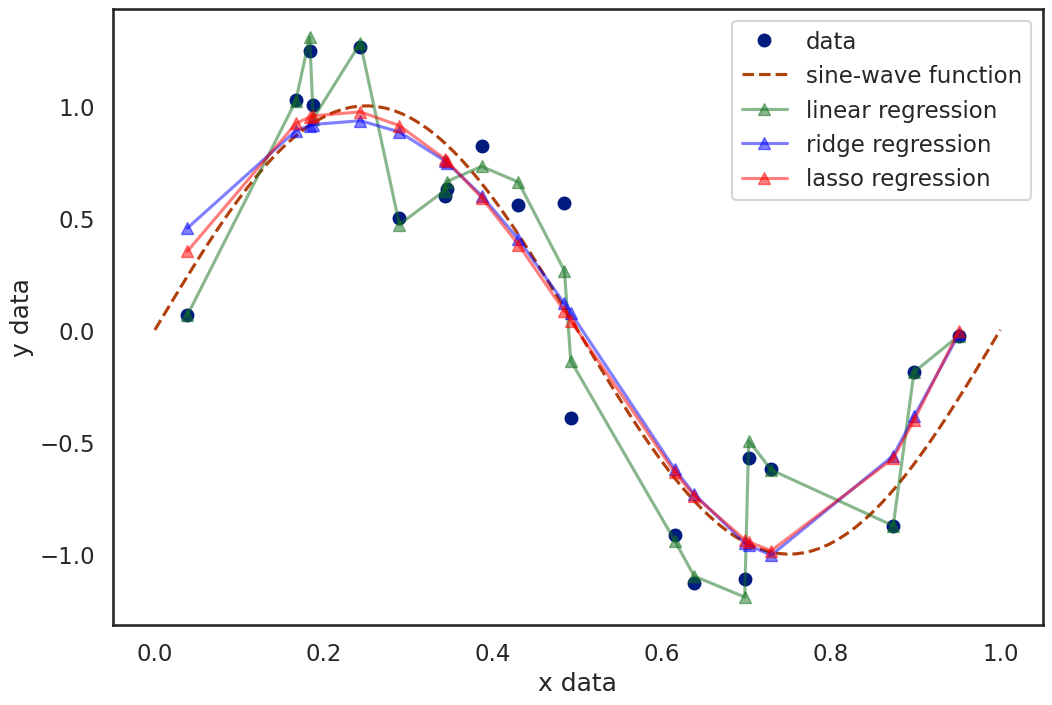

In [10]:
# The plot of the predicted values
plt.figure(figsize=(12,8))
plt.plot(X_data, Y_data, marker='o', ls='', label='data') # data points as per previous step
plt.plot(X_real, Y_real, ls='--', label='sine-wave function')  # sine-wave line as per previous step
plt.plot(X_data, Y_pred, label='linear regression', marker='^', alpha=.5) # predicted line with high polynomial features as per previous step
plt.plot(X_data, Y_pred_rr, label='ridge regression', marker='^', alpha=.5, color='blue') # ridge predicted line with regularization
plt.plot(X_data, Y_pred_lr, label='lasso regression', marker='^', alpha=.5, color='red')  # lasso predicted line with regularization

plt.legend()

ax = plt.gca()
ax.set(xlabel='x data', ylabel='y data');

In [21]:
# let's look at the absolute value of coefficients for each model
coefficients = pd.DataFrame()
coefficients['linear regression'] = lr.coef_
coefficients['ridge regression'] = rr.coef_
coefficients['lasso regression'] = lassor.coef_
coefficients = coefficients.map(abs) # transform into absolute values

print("coefficients:")
display(coefficients)

print("\ncoefficients.describe():")
display(coefficients.describe())  # Huge difference in scale between non-regularized vs regularized regression

print("\n(coefficients>0).sum():")
display((coefficients>0).sum())

coefficients:


,linear regression,ridge regression,lasso regression
0,2.008356e+08,0.000000,0.000000
1,1.866875e+06,6.065176,8.490500
2,4.539975e+07,12.429635,20.176708
3,6.133840e+08,4.070127,1.641353
4,5.270459e+09,2.307194,5.698488
5,3.076136e+10,4.432550,4.601939
6,1.258321e+11,4.135200,2.170905
7,3.631114e+11,2.883507,0.252181
8,7.233262e+11,1.484636,0.000000
9,9.201049e+11,0.307927,0.000000



coefficients.describe():


,linear regression,ridge regression,lasso regression
count,2.100000e+01,21.000000,21.000000
mean,2.427786e+11,2.169397,2.167284
std,2.709998e+11,2.900278,4.706731
min,1.866875e+06,0.000000,0.000000
25%,3.076136e+10,0.467578,0.000000
50%,1.258321e+11,1.017272,0.252181
75%,3.631114e+11,2.883507,1.641353
max,9.201049e+11,12.429635,20.176708



(coefficients>0).sum():


linear regression    21
ridge regression     20
lasso regression     15
dtype: int64

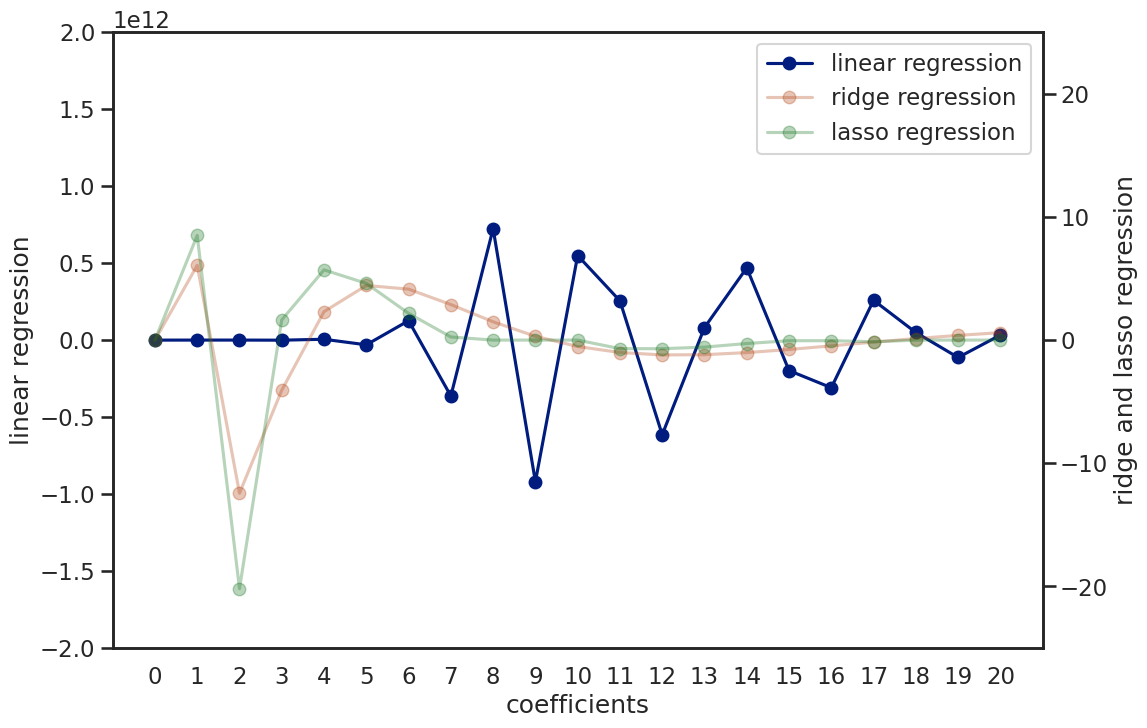

In [23]:
colors = sns.color_palette()
plt.figure(figsize=(12, 8))

# Setup the dual y-axes
ax1 = plt.axes()
ax2 = ax1.twinx()

# Plot the linear regression data
ax1.plot(lr.coef_.ravel(), color=colors[0], marker='o', label='linear regression')

# Plot the regularization data sets
ax2.plot(rr.coef_.ravel(),     color=colors[1], alpha=0.3, marker='o', label='ridge regression')
ax2.plot(lassor.coef_.ravel(), color=colors[2], alpha=0.3, marker='o', label='lasso regression')

# Customize axes scales
ax1.set_ylim(-2e12, 2e12)
ax2.set_ylim(-25, 25)

# Combine the legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2)

ax1.set(xlabel='coefficients',ylabel='linear regression')
ax2.set(ylabel='ridge and lasso regression')

ax1.set_xticks(range(len(lr.coef_)));